# Quality control of sc/snRNA-seq

To perform quality control of single-cell or single-nuclei RNA sequencing (sc/snRNA-seq) we have the `dotools_py.pp.importer_py()` function. This function compiles different methods to process samples. We need to define a list of H5 files that have been generated from a mapping tool like CellRanger or STARsolo. If CellBender has been run, we can also provide the path to the H5 files generated by CellBender. Additionally, we need to provide the batch names for the samples, and additional metadata can be provided in the form of a dictionary.

The quality control involves filtering genes and cells:
- **Genes**: are removed on their expression levels. Genes expressed in low amount of cells are excluded. By default, we consider that a gene is excluded if it is expressed in less than 5 cells
- **Cells**: are removed based on different parameters, including: number of genes, mitochondrial content, doublets and number of UMI counts.
    - Mitochondrial content: cells with high mitochondrial content are excluded. We recomment assuming a maximum un 5 % for scRNA-seq and 3% for snRNA-seq
    - Doublets: we implemented three different approaches for the identification of neotypic doublets (i.e, doublets originating from the combination of two or more different cell-types). The available implementations are [scDblFinder](https://github.com/plger/scDblFinder), [DoubletDetection](https://github.com/JonathanShor/DoubletDetection) and [Scrublet](https://github.com/swolock/scrublet).
    - Number of genes: cells are removed by absolute number of genes. A lower and upper threshold can be set.
    - Number of UMI counts: cells can be removed using two approaches: absolute or quantiles. A lower and upper threshold can be set and a combination of both approaches can be used (e.g., an absolute lower threshold and filter cells on the upper quantile).

After the quality control per sample, the individual samples will be combined into one AnnData object and log-normalisation, scaling and highly variable genes  will be calculated. To evaluate the quality control the distribution of total UMI, number of genes and mitochondrial genes per cell will be plotted in a violin plot before and after the quality control. These plots will be saved in the folders containing the H5 files. Additionally, we also keep track on the number of cells and genes that have been removed in each quality control step.

First, we start setting up the environment and loading the required libraries

In [1]:
# Set-Up
import dotools_py as do

2025-06-18 09:23:25,200 - Jupyter enviroment detected. Using "inline" backend


To show how the quality control works, we are going to use a public dataset from 10X from human blood of healthy and donors with a malignant tumor. We get the raw and the filtered H5 files generated by 10X.

In [2]:
do.dt.example_10x()

2025-06-18 09:13:52,374 - Downloading data to /tmp/dootools_datasets/


In [ ]:
paths = ['/tmp/dootools_datasets/healthy/outs/filtered_feature_bc_matrix.h5',
         '/tmp/dootools_datasets/disease/outs/filtered_feature_bc_matrix.h5']

adata = do.pp.importer_py(paths=paths,
                          ids=['batch1', 'batch2'],
                          metadata={'condition':['healthy', 'disease']},  # Additional metadata information
                          batch_key='batch',  # Column in obs to save batch information
                          remove_doublets=True,
                          doublet_tool='scDblFinder',  # Tool to identify neotypic doublets (Also available Scrublet and DoubletDetection)
                          min_genes_in_cell=300,
                          min_cells_with_genes=5,
                          cut_mt=5,
                          n_reads=10_000,
                          min_counts=500,  # Filter cells with less than 500 genes
                          high_quantile=95  # Filter cells with the top 5% high number of UMI counts
                          )

2025-06-18 09:14:08,285 - Reading batch1
reading /tmp/dootools_datasets/healthy/outs/filtered_feature_bc_matrix.h5
 (0:00:00)
2025-06-18 09:14:10,032 - Remove Cells with low number of genes
filtered out 14 cells that have less than 300 genes expressed
2025-06-18 09:14:10,170 - Remove Genes lowly expressed
filtered out 16694 genes that are detected in less than 5 cells
2025-06-18 09:14:10,367 - Remove cells with high MT-content
2025-06-18 09:14:10,388 - Remove cells based on nUMI counts
2025-06-18 09:14:10,431 - Finding Neotypic doublets


... storing 'batch' as categorical
... storing 'condition' as categorical
... storing 'feature_types' as categorical
... storing 'genome' as categorical
... storing 'pattern' as categorical
... storing 'read' as categorical
... storing 'sequence' as categorical


2025-06-18 09:14:10,639 - Running scDblFinder


During startup - Warning messages:
1: Setting LC_COLLATE failed, using "C" 
2: Setting LC_TIME failed, using "C" 
3: Setting LC_MESSAGES failed, using "C" 
4: Setting LC_MONETARY failed, using "C" 
5: Setting LC_PAPER failed, using "C" 
6: Setting LC_MEASUREMENT failed, using "C" 
Reading AnnData in R
trying URL 'https://repo.anaconda.com/miniconda/Miniconda3-py39_4.12.0-Linux-x86_64.sh'
Content type 'application/x-sh' length 76607678 bytes (73.1 MB)
downloaded 73.1 MB



PREFIX=/home/davidr/snap/jupyterlab-desktop/common/.cache/R/basilisk/1.16.0/0
Unpacking payload ...


Solving environment: ...working... done

## Package Plan ##

  environment location: /home/davidr/snap/jupyterlab-desktop/common/.cache/R/basilisk/1.16.0/0

  added / updated specs:
    - _libgcc_mutex==0.1=main
    - _openmp_mutex==4.5=1_gnu
    - brotlipy==0.7.0=py39h27cfd23_1003
    - ca-certificates==2022.3.29=h06a4308_1
    - certifi==2021.10.8=py39h06a4308_2
    - cffi==1.15.0=py39hd667e15_1
    - charset-normalizer==2.0.4=pyhd3eb1b0_0
    - colorama==0.4.4=pyhd3eb1b0_0
    - conda-content-trust==0.1.1=pyhd3eb1b0_0
    - conda-package-handling==1.8.1=py39h7f8727e_0
    - conda==4.12.0=py39h06a4308_0
    - cryptography==36.0.0=py39h9ce1e76_0
    - idna==3.3=pyhd3eb1b0_0
    - ld_impl_linux-64==2.35.1=h7274673_9
    - libffi==3.3=he6710b0_2
    - libgcc-ng==9.3.0=h5101ec6_17
    - libgomp==9.3.0=h5101ec6_17
    - libstdcxx-ng==9.3.0=hd4cf53a_17
    - ncurses==6.3=h7f8727e_2
    - openssl==1.1.1n=h7f8727e_0
    - pip==21.2.4=py39h06a4308_0
    - pycosat==0.6.3=py39h27cfd23_0
    - p

+ /home/davidr/snap/jupyterlab-desktop/common/.cache/R/basilisk/1.16.0/0/bin/conda create --yes --prefix /home/davidr/snap/jupyterlab-desktop/common/.cache/R/basilisk/1.16.0/zellkonverter/1.14.1/zellkonverterAnnDataEnv-0.10.6 'python=3.12.2' --quiet -c conda-forge


Solving environment: ...working... failed with repodata from current_repodata.json, will retry with next repodata source.
Solving environment: ...working... 

In [ ]:
adata

We can now check the quality control plots for:

In [5]:
from IPython.display import display, HTML

files = [
    '/tmp/dootools_datasets/healthy/outs/Vln_PreQC_batch1.svg',
    '/tmp/dootools_datasets/healthy/outs/Vln_PostQC_batch1.svg',
    '/tmp/dootools_datasets/healthy/outs/250612_QC_Metricsbatch1.svg'
]

html = f'''
<div style="display:flex; gap:10px; align-items:flex-start; margin-bottom:10px;">
    <img type="image/svg+xml" data="{files[0]}" style="max-height:500px; width:auto; flex-shrink:0;"></object>
    <img type="image/svg+xml" data="{files[1]}" style="max-height:500px; width:auto; flex-shrink:0;"></object>
</div>
<div style="display:flex; gap:10px; align-items:flex-start;">
    <img type="image/svg+xml" data="{files[2]}" style="max-height:800px; width:auto; flex-shrink:0;"></object>
</div>
'''


display(HTML(html))

We can observe that the majority of cells were remove due to high mitochondrial content. Depending on the experimental set-up we might want to increase the threshold of mitochondrial content if we do not want to lose too many cells.

## Integration
After the quality control, we can now proceed to the batch correction and integration of the samples. For these, we can use different batch correction methods: Harmony, Scanorama, BBKNN, scVI and CCA from Seurat (v4 or v5 approach). After the integration of the samples, we run the Leiden algorithm to find clusters and generate the UMAP embeddings for visualisation.

In [6]:
do.tl.integrate_data(adata,
                     batch_key='batch',
                     hvg_batch=True, # Take HVG shared across samples
                     cca4=True,
                     resolution=0.3,  # Resolution for leiden algorithm
                     )

2025-06-14 11:27:29,985 - Computing HVGs
extracting highly variable genes
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:00)
2025-06-14 11:27:31,411 - Integration using CCA (Seurat v4 approach)
2025-06-14 11:27:31,423 - Preprocessing to export to Seurat
2025-06-14 11:27:31,549 - Running CCA Integration


Reading AnnData in R
Warning messages:
1: `PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>. 
2: The `slot` argument of `SetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>. 
3: Keys should be one or more alphanumeric characters followed by an underscore, setting key from X_pca_ to Xpca_ 
Starting ACC in R environment...
Run CCA with v4
Scaling features for provided objects
Finding all pairwise anchors
Running CCA
Merging objects
Finding neighborhoods
Finding anchors
	Found 3054 anchors
Filtering anchors
	Retained 2049 anchors
Merging dataset 2 into 1
Extracting anchors for merged samples
Finding integration vectors

                          A2M-AS1 A4GALT      AATK
AAACCCAGTGCATTTG-1-batch1       0      0 0.8126703
AAACCCATCTCAACGA-1-batch1       0      0 0.0000000
AAACCCATCTCTCGAC-1-batch1       0      0 0.0000000
2025-06-14 11:28:05,498 - Loading corrected matrix
2025-06-14 11:28:07,774 - Using CCA matrix for PCA
computing PCA
    with n_comps=50
    finished (0:00:00)
2025-06-14 11:28:08,652 - Finding neighbors
computing batch balanced neighbors
	finished (0:00:02)
2025-06-14 11:28:10,827 - Run UMAP
computing UMAP
    finished (0:00:03)
2025-06-14 11:28:14,012 - Clustering cells using Leiden (resolution 0.3)
running Leiden clustering
    finished (0:00:00)


In [7]:
adata

AnnData object with n_obs × n_vars = 2801 × 18517
    obs: 'batch', 'condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'n_counts', 'doublet_class', 'doublet_score', 'leiden'
    var: 'mean', 'std', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'X_pca', 'X_CCA', 'X_umap'
    varm: 'PCs'
    layers: 'counts', 'logcounts', 'scaled'
    obsp: 'distances', 'connectivities'

 We can observe, that after the integration we have `X_CCA` in `obsm`. This is the corrected expression matrix that is generated from running CCA in Seurat. In this case, we use the implementation from v4, so the dimensions of this matrix is  n_cells x n_hvg.

In [8]:
adata.obsm['X_CCA'].shape

(2801, 1758)

We can now visualise the integrated object and the identified clusters:

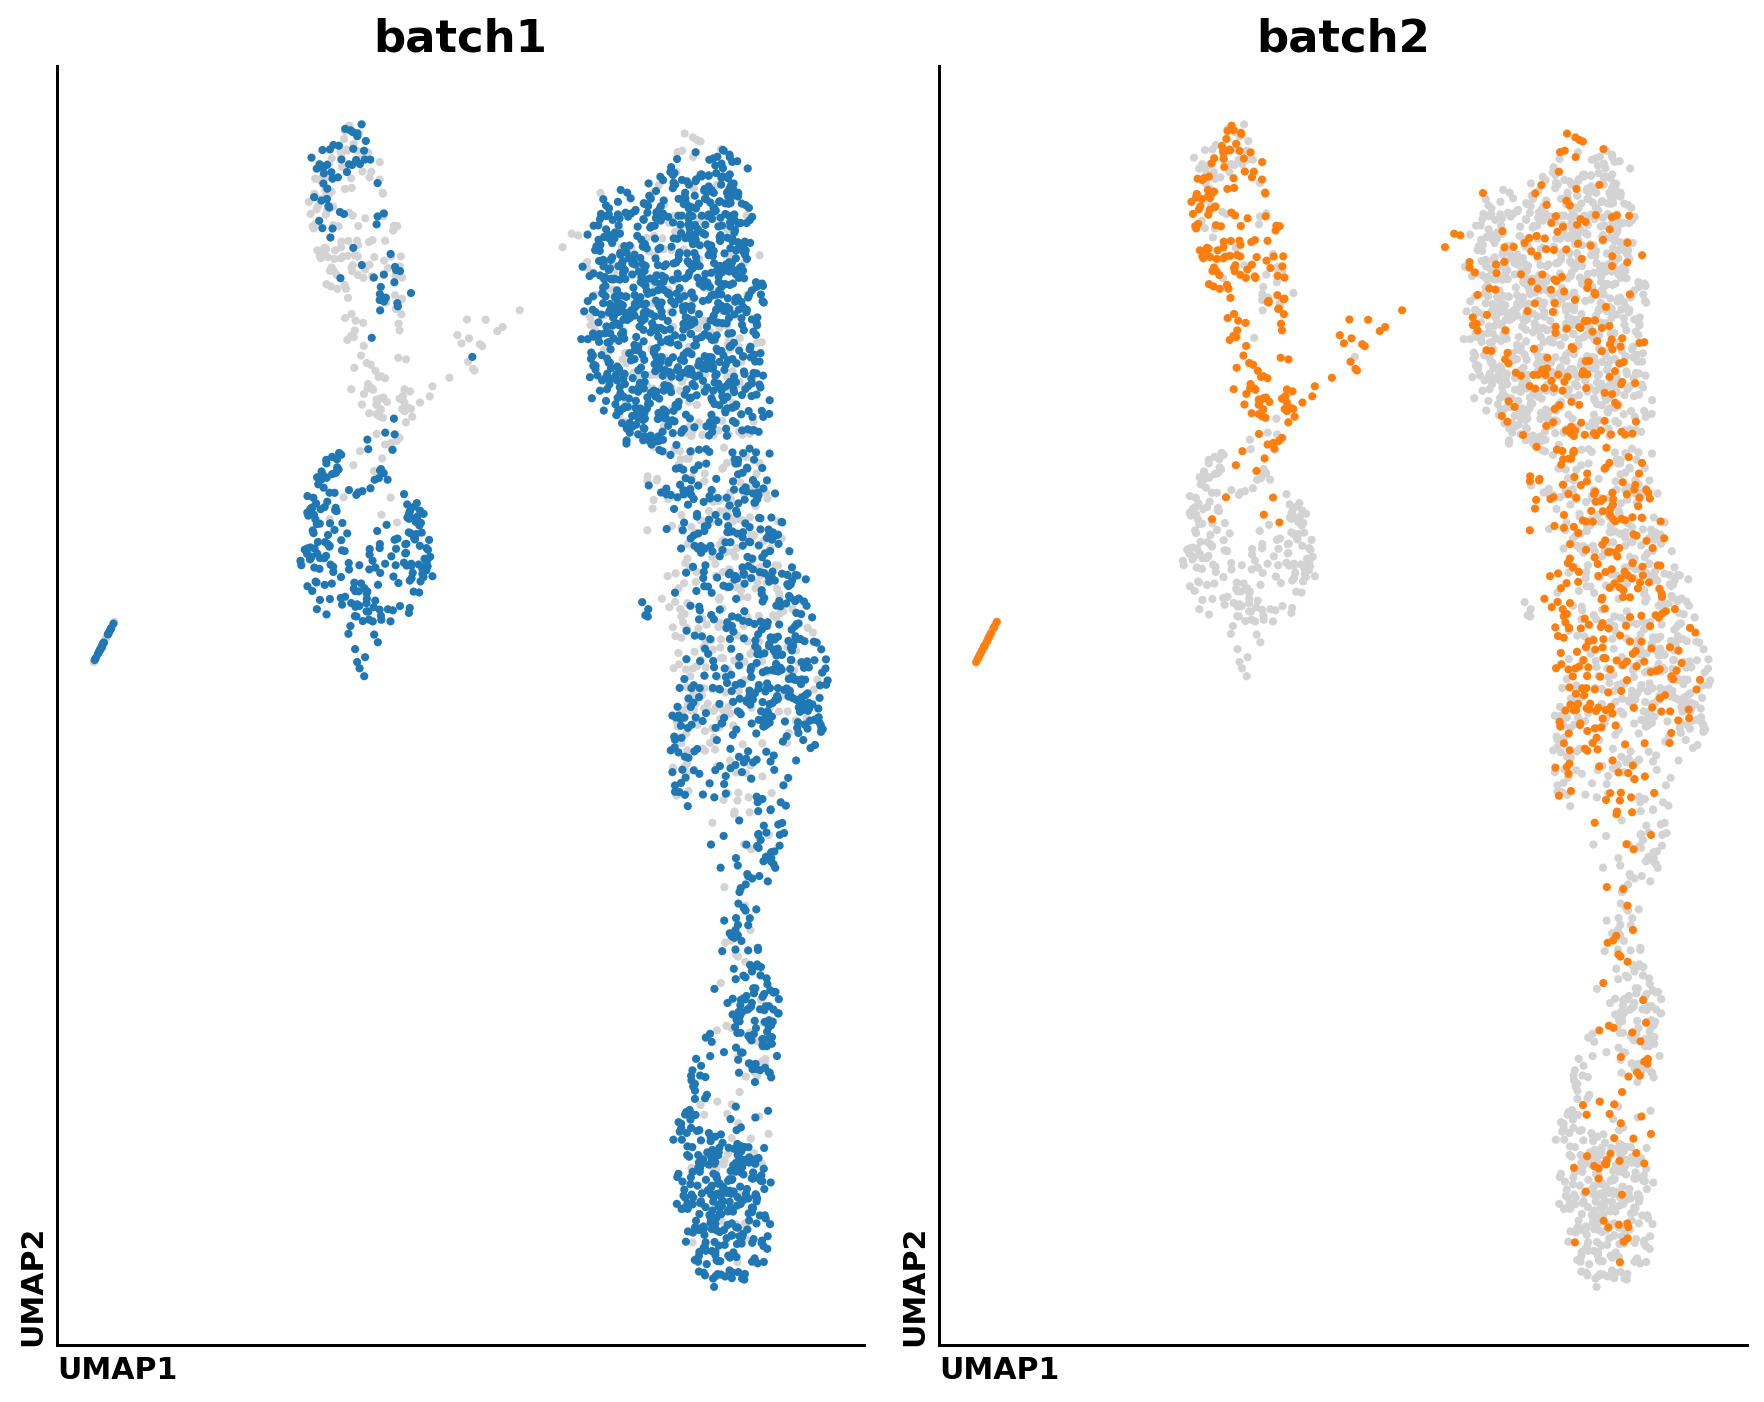

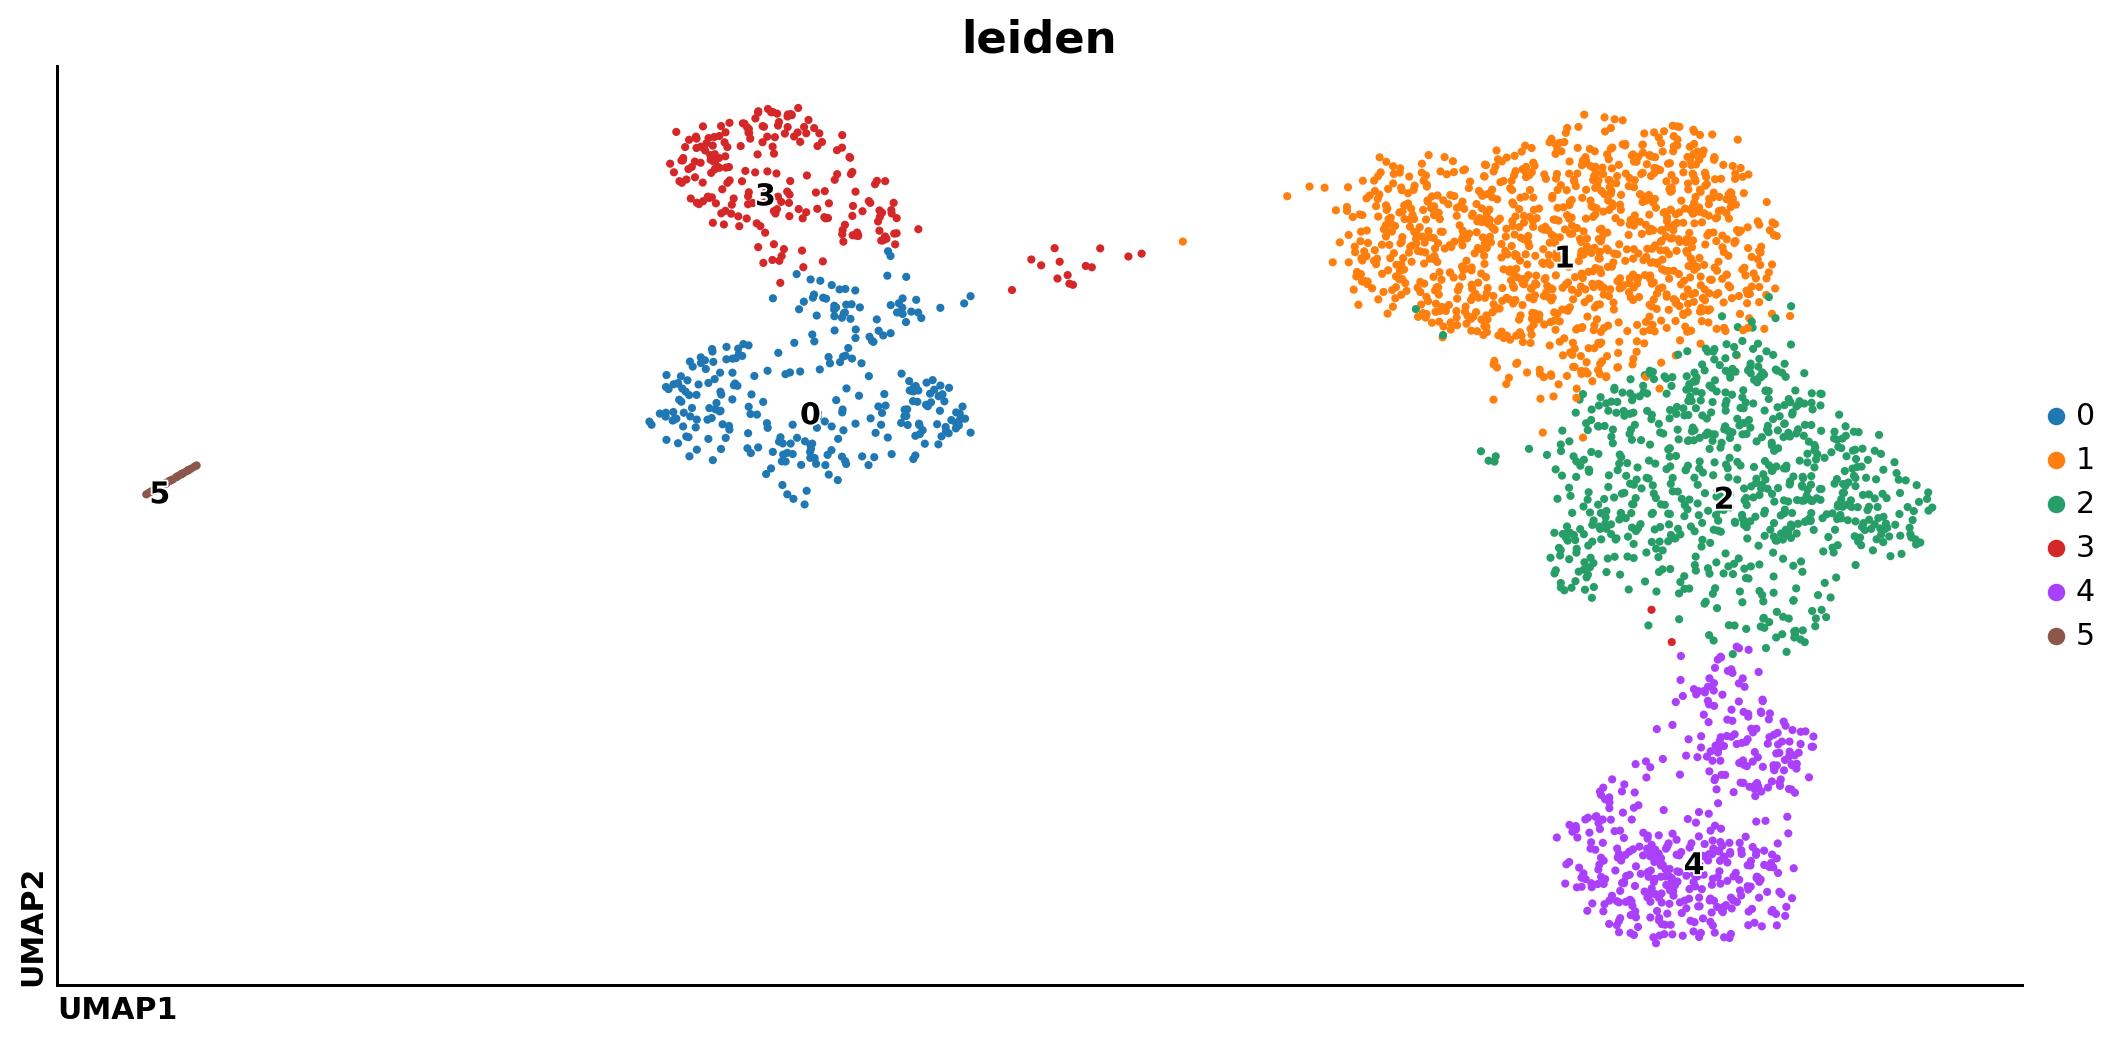

In [9]:
do.pl.split_embeddding(adata, 'batch')
do.pl.umap(adata, 'leiden', labels='leiden')

## Semi-automatic annotation with CellTypist

We also have the possibility to perform a semi-automatic annotation using [CellTypist](https://www.celltypist.org/). In this case, we use the  `Adult_COVID19_PBMC.pkl` model.

👉 Detailed model information can be found at `https://www.celltypist.org/models`
🔬 Input data has 2801 cells and 18517 genes
🔗 Matching reference genes in the model
🧬 3323 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


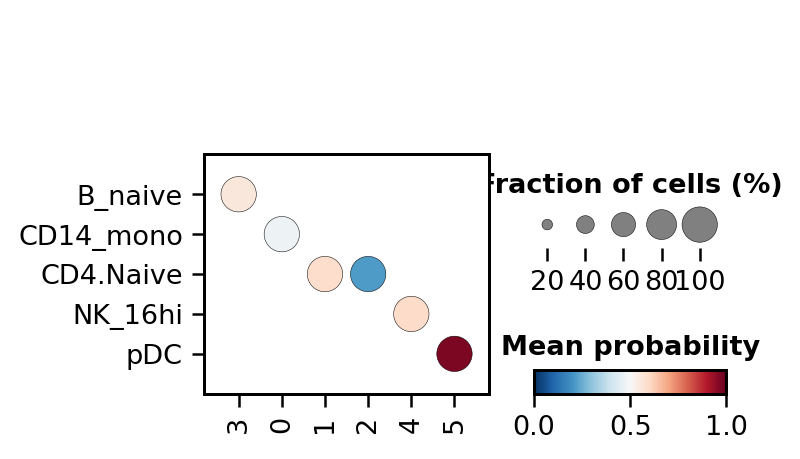

In [10]:
adata = do.tl.auto_annot(adata, 'leiden', model='Healthy_COVID19_PBMC.pkl', convert=False, pl_cell_prob=True)

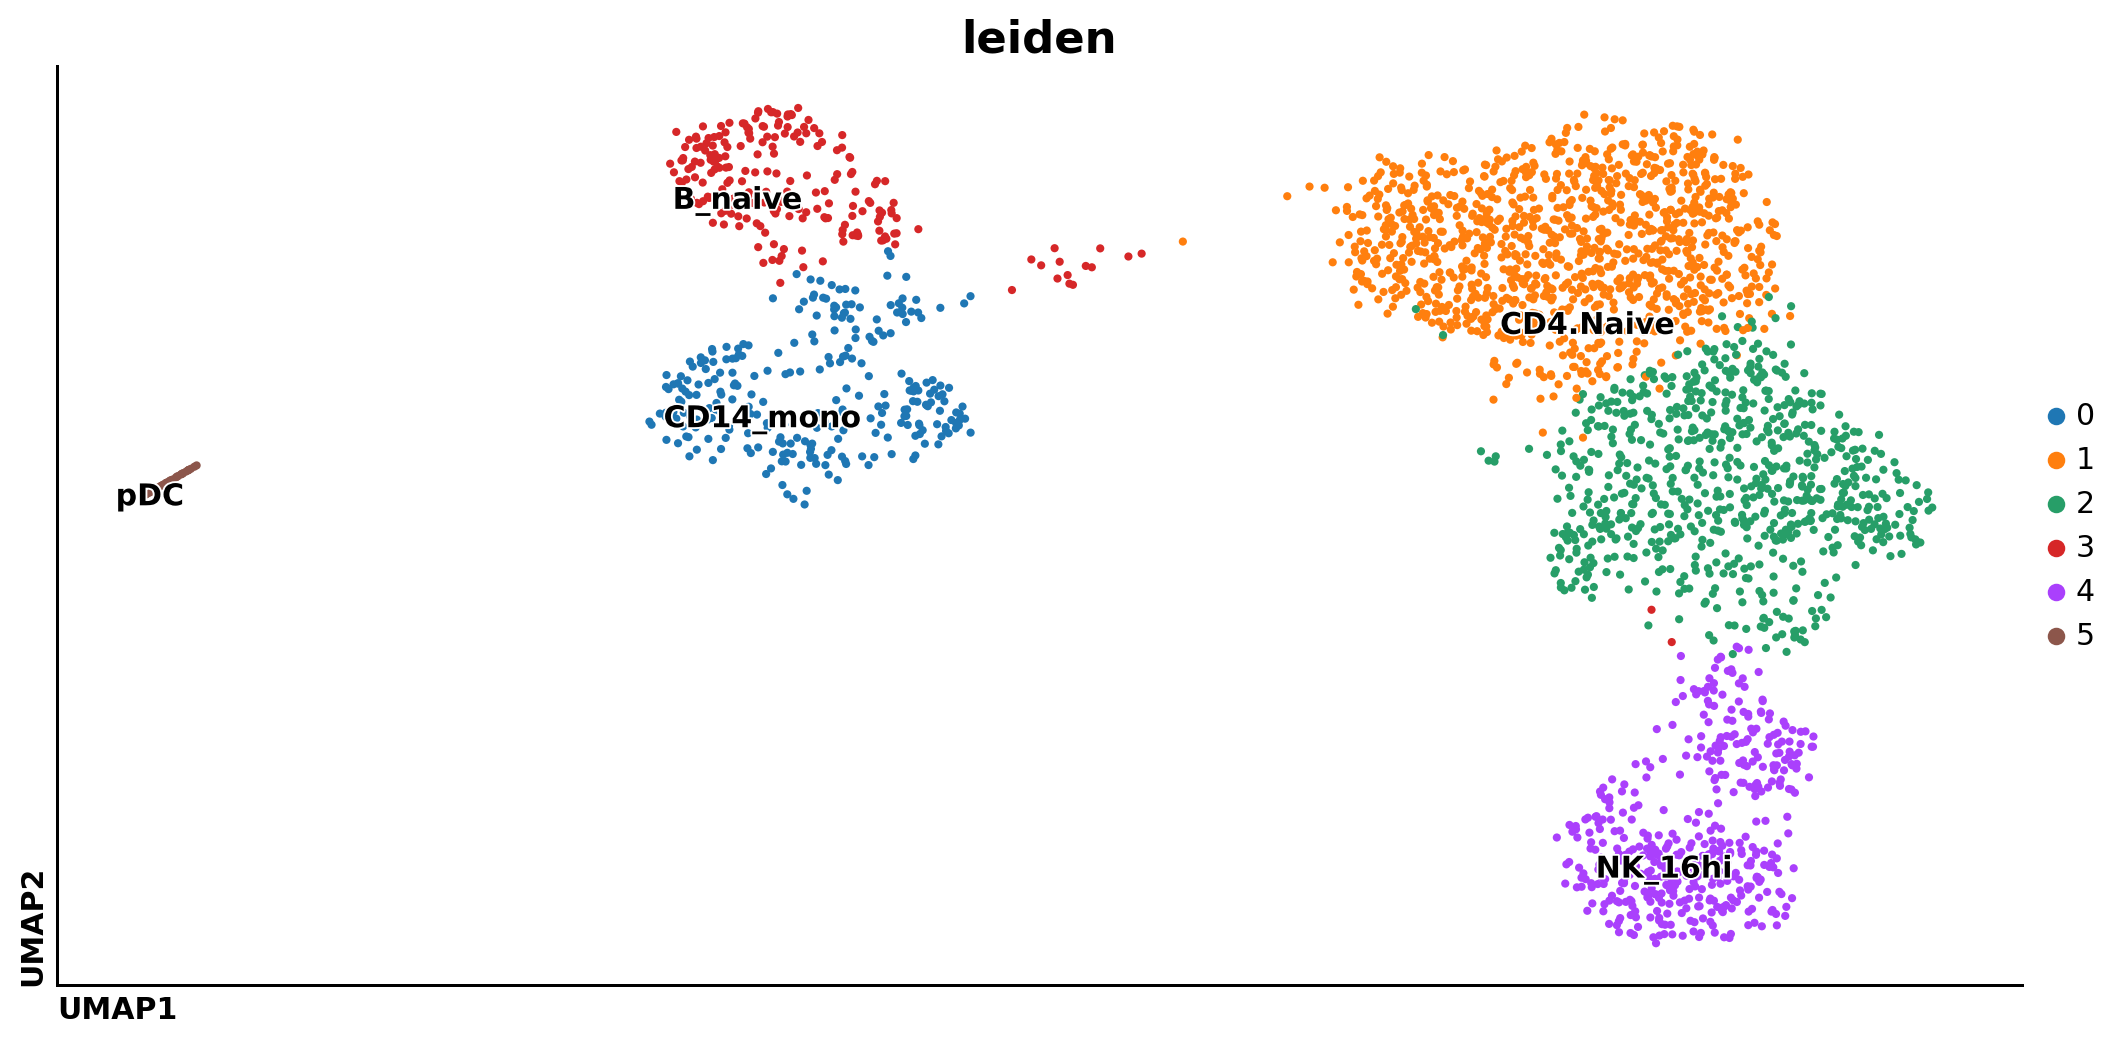

In [34]:
do.pl.umap(adata, 'leiden', labels='autoAnnot')

Besides the semi-automatic annotation, we should also validate the findings with  known markers for these celltypes.


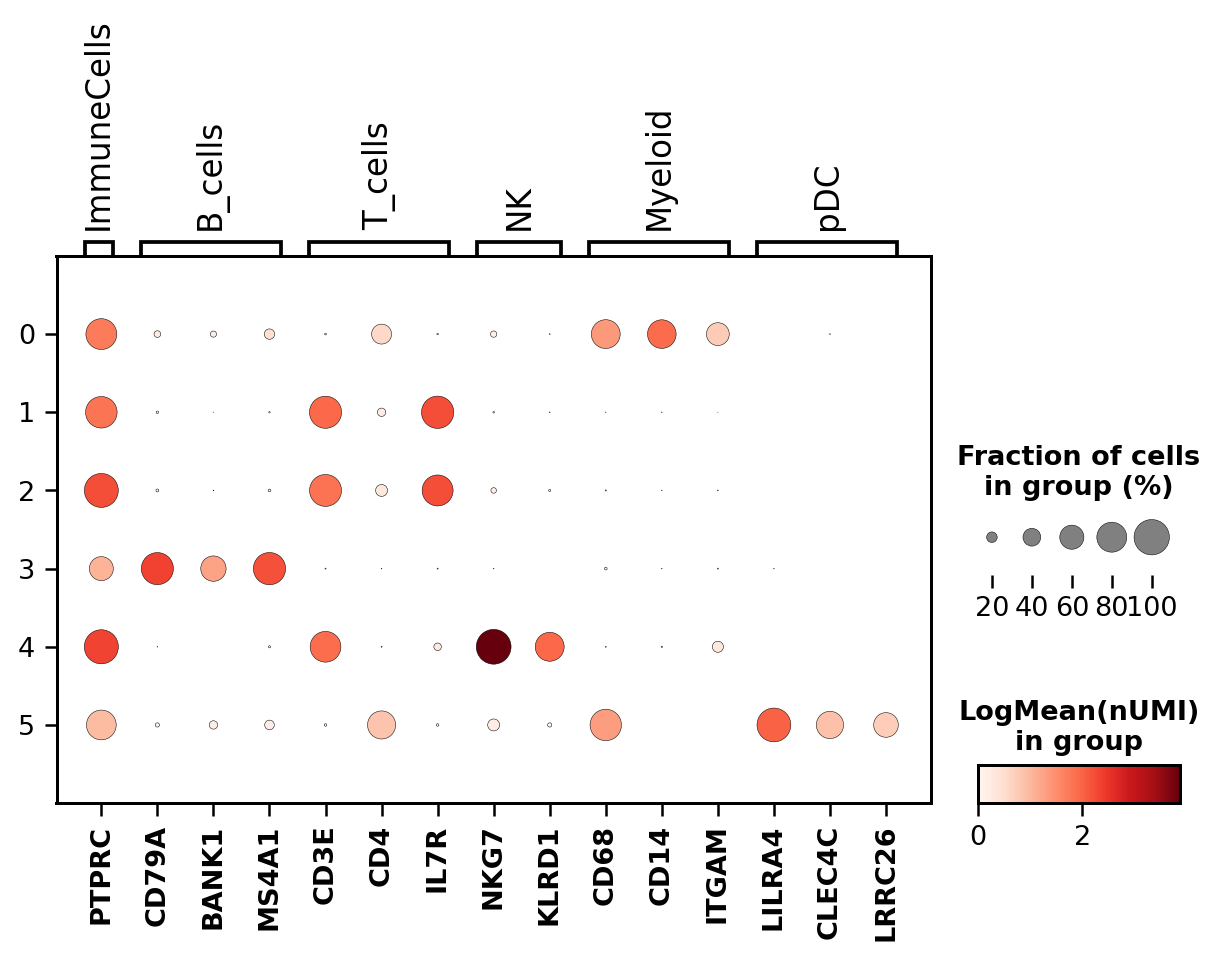

In [37]:
markers = {'ImmuneCells': ['PTPRC'],
           'B_cells': ['CD79A', 'BANK1', 'MS4A1'],
           'T_cells': ['CD3E', 'CD4', 'IL7R'],
           'NK': ['NKG7', 'KLRD1'],
           'Myeloid': ['CD68', 'CD14', 'ITGAM'],
           'pDC': ['LILRA4', 'CLEC4C', 'LRRC26']}

do.pl.dotplot(adata, 'leiden', markers, swap_axes=False)

Overall we can see an agreement with the annotation and can continue with the annotation.

... storing 'annotation' as categorical


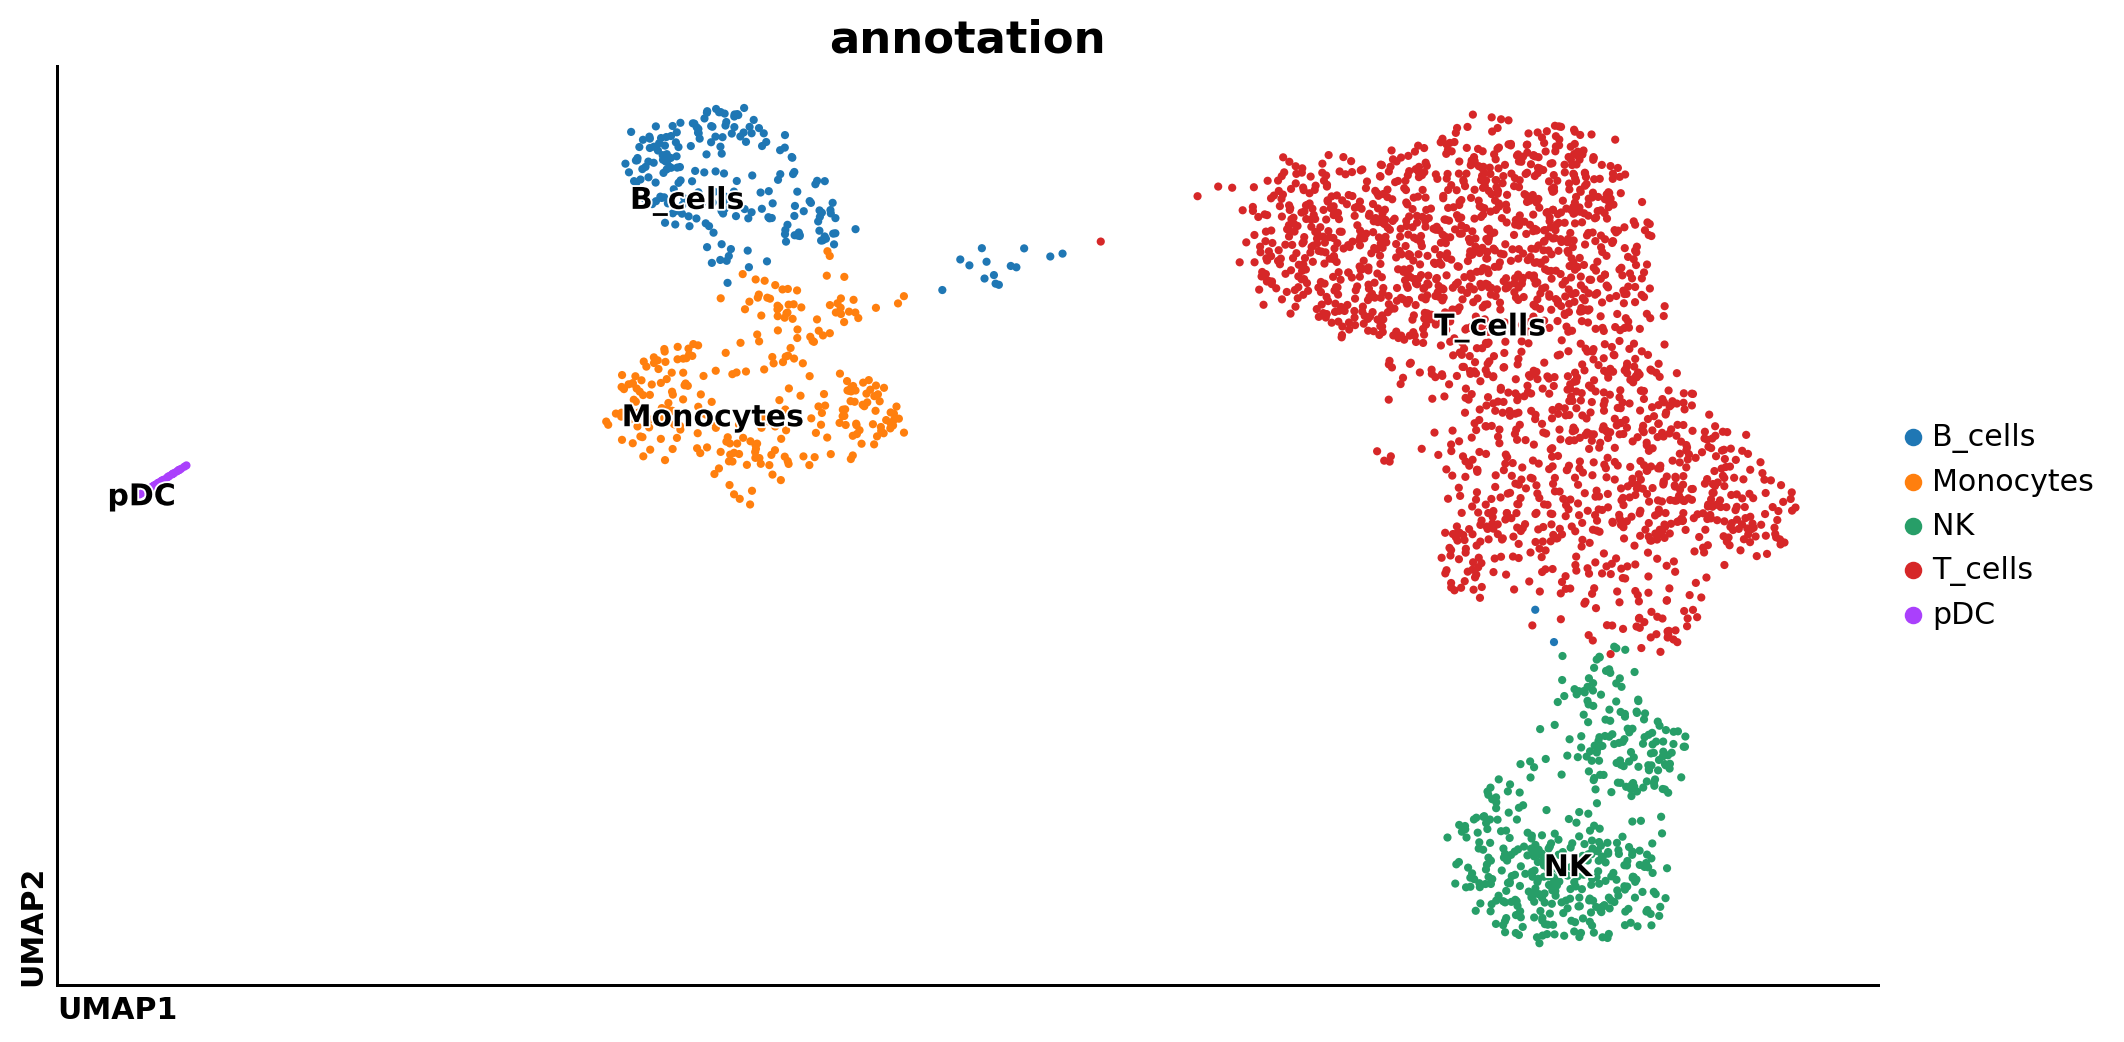

In [40]:
adata.obs['annotation'] = adata.obs.leiden.map({'0': 'Monocytes', '1': 'T_cells', '2': 'T_cells', '3': 'B_cells',
                                                '4': 'NK', '5': 'pDC'})
do.pl.umap(adata, 'annotation', labels='annotation')

After the identification of the celltype populations, we can also evaluate if there are significant changes in these populations in the healthy and diseased condition using [scanpro](https://github.com/loosolab/scanpro).

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[WARNING] Consider setting transform='arcsin', as this produces more accurate results for simulated data.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 4.01 seconds
2025-06-14 12:06:46,820 - There are 1 populations with a significant change


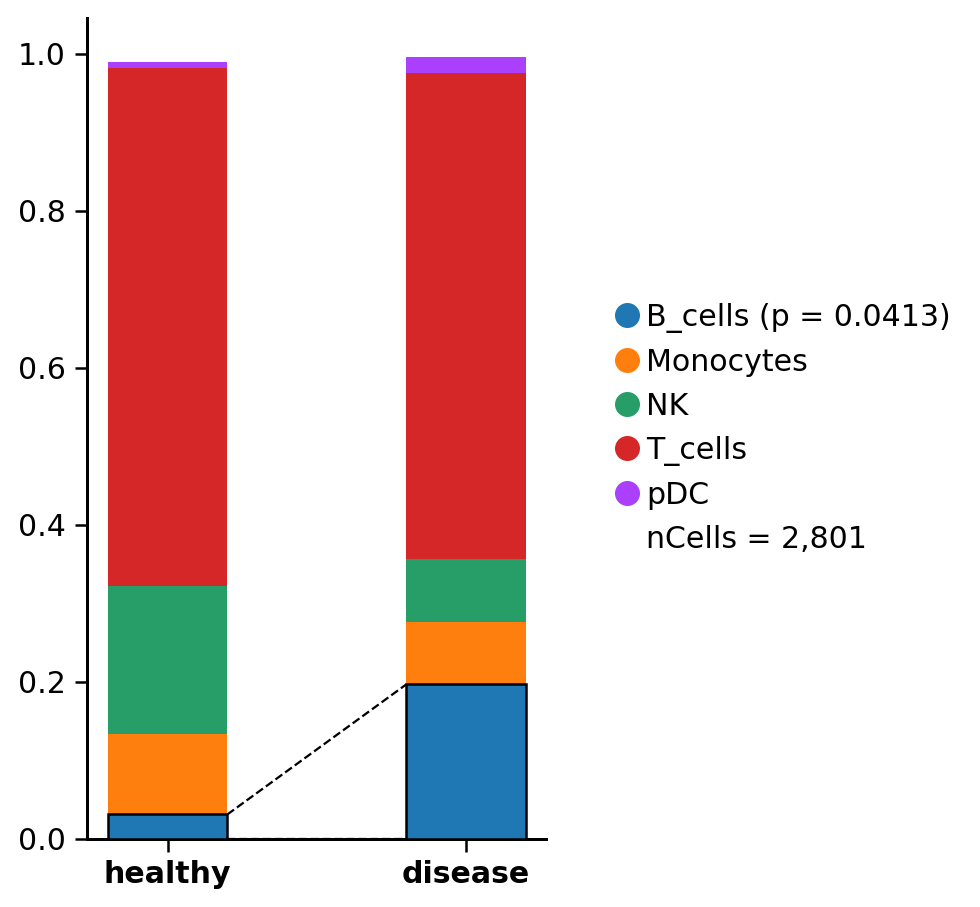

In [41]:
do.pl.cell_props(adata,
                 annot_key='annotation',
                 cond_key='condition',
                 batch_key='batch',
                 cond_order=['healthy', 'disease'])

Cell populations with a significant change are connected by discontinued lines and the p-value is indicated in the legend. In this case, we see a significant change in B cells assuming a significant threshold of 0.05.

## Reclustering of cell population

If we are interested in specific states for a celltypes, we can also perform re-clustering. In this case, we are going to focus on the biggest cluster, the T cells.

2025-06-14 12:14:00,575 - Reclustering using CCA4 approach
computing PCA
    with n_comps=50
    finished (0:00:01)
computing batch balanced neighbors
	finished (0:00:00)
computing UMAP
    finished (0:00:01)
running Leiden clustering
    finished (0:00:00)


... storing 'annotation_recluster' as categorical


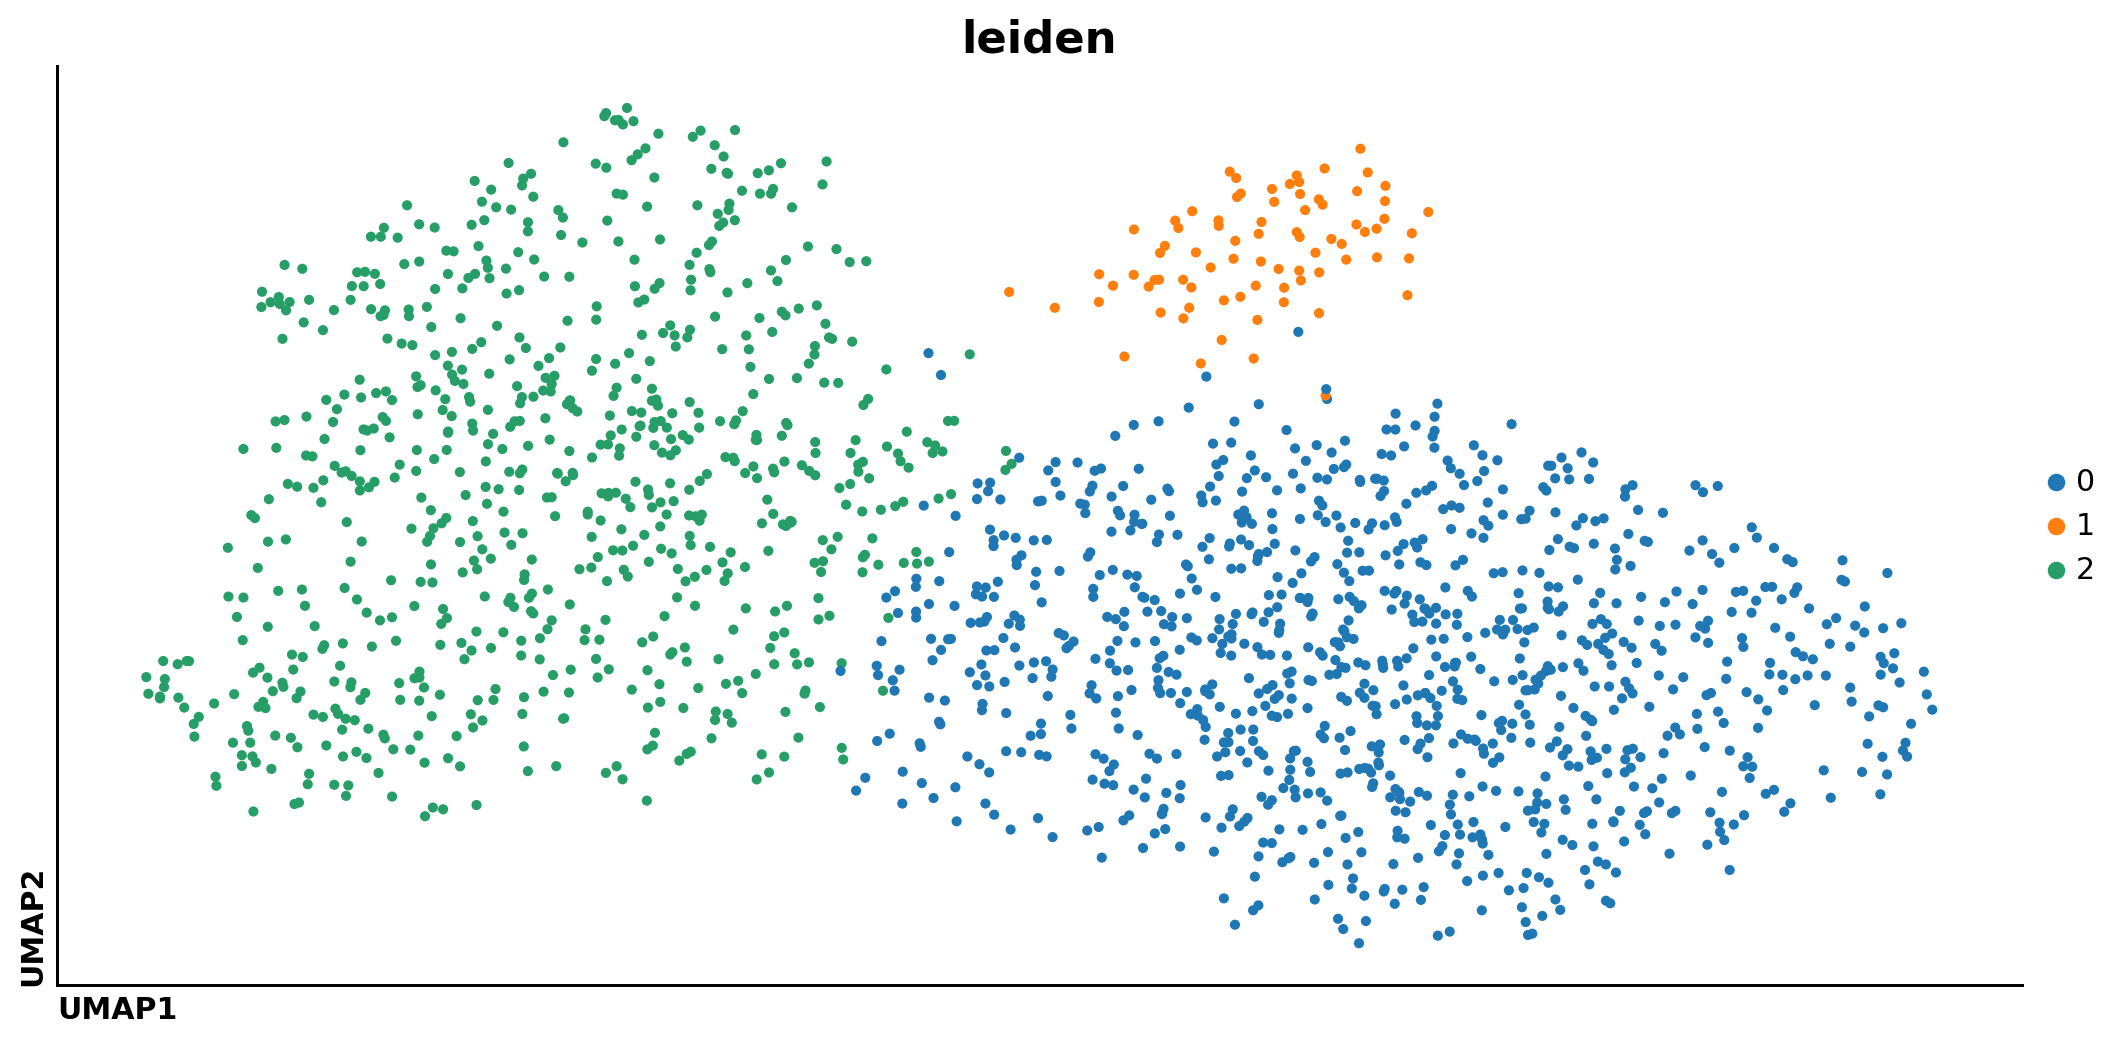

In [45]:
tcell = do.tl.reclustering(adata,
                           cluster_key='annotation',  # Metadata column with clusters
                           batch_key='batch',  # Metadata column with batch information
                           recluster_apporach='CCA4',  # Integration approach used
                           use_clusters=['T_cells'],  # Cluster we want to re-cluster
                           use_rep='X_CCA',  # representation to use
                           get_subset=True,  # Get AnnData of T_cells re-clusters
                           automatic_annot=False
                           )
do.pl.umap(tcell, 'leiden')

We identified 3 clusters, to evaluate if there are subtypes of T_cells we can identify the top markers for each cluster.

In [49]:
do.tl.rank_genes_groups(tcell, groupby='leiden', method='wilcoxon', tie_correct=True, pts=True)
table = do.tl.generate_results(tcell)
table_filt = table[(table.log2fc > 0.5) & (table.padj < 0.05)]

for group in table_filt.group.unique():
    display(table_filt[table_filt.group == group].head(10))

ranking genes
    finished (0:00:07)


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
0,0,RPS3A,24.712906,0.601503,7.770967e-135,7.194750e-131,1.000000,0.993865
1,0,RPS13,23.831327,0.649803,1.581724e-125,7.322198e-122,1.000000,0.993865
11,0,RPS5,17.674942,0.512448,6.540654e-70,6.374383e-67,0.999005,0.988957
21,0,EEF1B2,16.179941,0.598423,6.986192e-59,3.696095e-56,0.989055,0.961963
26,0,RPS26,14.902431,0.585934,3.178066e-50,1.200985e-47,0.962189,0.926380
30,0,SELL,13.655512,0.851286,1.871700e-42,5.874282e-40,0.851741,0.587730
32,0,LEF1,13.580381,1.137301,5.235287e-42,1.589210e-39,0.651741,0.366871
44,0,TCF7,11.867242,0.908731,1.751463e-32,3.487295e-30,0.705473,0.493252
45,0,CCR7,11.857168,1.063518,1.975439e-32,3.850442e-30,0.572139,0.306748
47,0,EIF3E,11.422065,0.551860,3.244321e-30,5.614495e-28,0.930348,0.861350


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
18517,1,LINC02446,32.375385,6.476617,6.096044e-230,1.128804e-225,0.759494,0.009765
18518,1,CD8B,31.202486,5.865994,9.858211e-214,9.127224e-210,0.873418,0.024124
18519,1,CD8A,31.069324,5.363335,6.255875e-212,3.861334e-208,0.810127,0.017231
18520,1,CD8B2,14.423173,6.192301,3.699363e-47,1.712528e-43,0.151899,0.001723
18521,1,CTSW,13.606427,2.544368,3.667409e-42,1.358188e-38,0.670886,0.128087
18522,1,S100B,13.162360,5.951654,1.445012e-39,4.459549e-36,0.139241,0.002298
18523,1,FCER1G,12.313405,3.100331,7.671680e-35,2.029379e-31,0.303797,0.026996
18524,1,FBLN2,10.607231,4.911227,2.758002e-26,6.383741e-23,0.101266,0.002298
18525,1,KLRC4,9.185306,5.124489,4.103612e-20,8.442953e-17,0.075949,0.001723
18526,1,DSEL,9.166381,4.315569,4.891682e-20,9.057928e-17,0.139241,0.009765


,group,GeneName,wilcox_score,log2fc,pvals,padj,pts_group,pts_ref
37034,2,B2M,28.245174,0.679558,1.631502e-175,3.021052e-171,1.000000,1.000000
37035,2,S100A4,25.990732,2.790944,6.303371e-149,2.917988e-145,0.881793,0.445572
37036,2,HLA-A,21.963623,0.983503,6.417157e-107,1.320294e-103,0.990489,0.954797
37037,2,ITGB1,21.894226,3.038321,2.948743e-106,5.460187e-103,0.580163,0.110701
37038,2,ANXA2,20.307739,4.080093,1.098451e-91,1.271251e-88,0.403533,0.027675
37039,2,SH3BGRL3,19.706732,1.256049,1.887694e-86,1.839707e-83,0.934783,0.779520
37040,2,HLA-B,19.342152,0.588217,2.373654e-83,2.092998e-80,1.000000,0.998155
37041,2,UBC,19.332321,0.992277,2.872062e-83,2.417362e-80,0.982337,0.933579
37042,2,SRGN,19.200706,1.655207,3.650927e-82,2.816842e-79,0.865489,0.434502
37043,2,TNFRSF4,18.895252,4.259522,1.247878e-79,8.558132e-77,0.350543,0.022140


From this list of markers, we can see that cluster 1 is enriched for cytotoxic markers. We can transfer this annotation to our original object and evaluate again changes in the cell population.

... storing 'annotation_recluster' as categorical


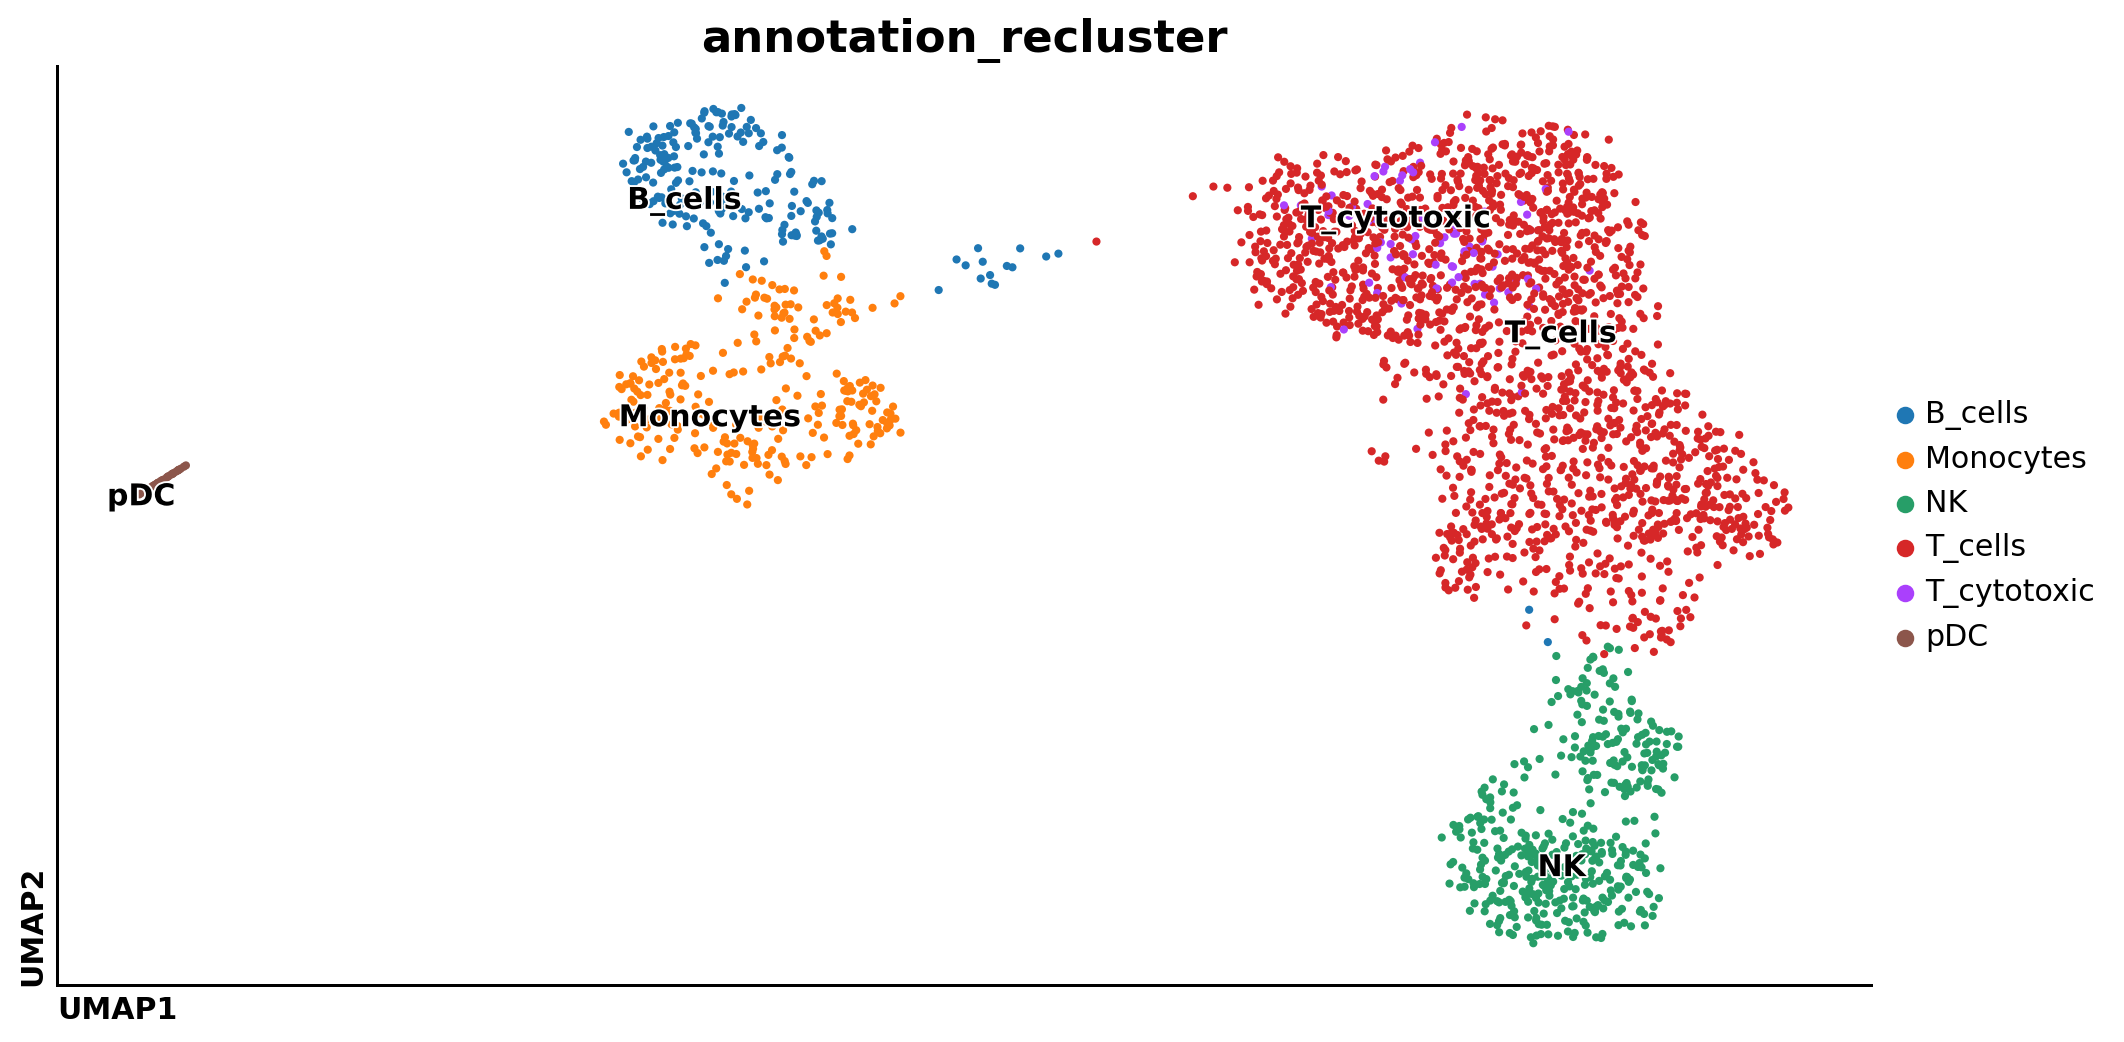

In [50]:
tcell.obs['annotation_recluster'] = tcell.obs.leiden.map({'0': 'T_cells', '1': 'T_cytotoxic', '2':'T_cells'})
adata.obs['annotation_recluster'] = adata.obs['annotation'].copy()
do.utility.transfer_labels(adata_original=adata,
                           adata_subset=tcell,
                           original_key='annotation_recluster',
                           subset_key='annotation_recluster',
                           original_labels=['T_cells']
                           )
do.pl.umap(adata, 'annotation_recluster', labels='annotation_recluster')

[INFO] Your data doesn't have replicates! Artificial replicates will be simulated to run scanpro.
[WARNING] Consider setting transform='arcsin', as this produces more accurate results for simulated data.
[INFO] Simulation may take some minutes...
[INFO] Generating 3 replicates and running 100 simulations...
[INFO] Finished 100 simulations in 4.26 seconds
2025-06-14 12:28:39,718 - There are 1 populations with a significant change


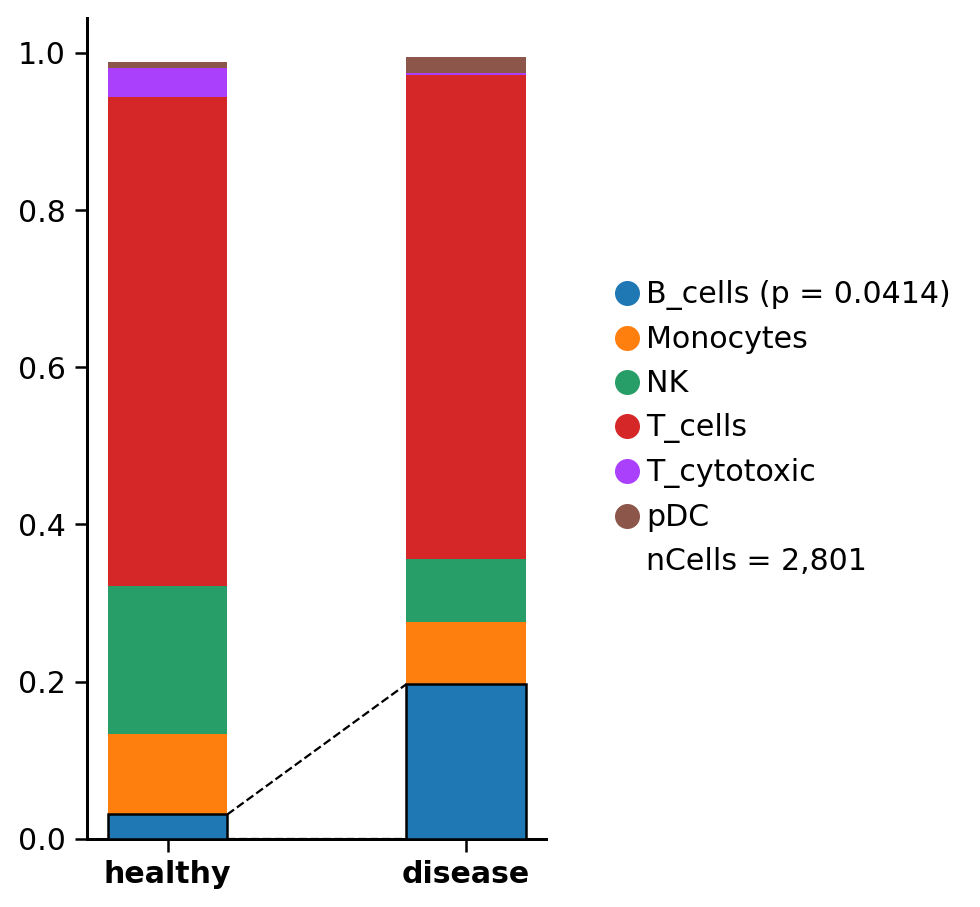

In [52]:
do.pl.cell_props(adata,
                 annot_key='annotation_recluster',
                 cond_key='condition',
                 batch_key='batch',
                 cond_order=['healthy', 'disease']
                 )

We can see that even though there is a decrease in the proportion of T_cytotoxic, the change is not significant.

## Gene Ontology analysis

We can also evaluate which biological processes are enriched in a celltype in each condition by performing gene ontology analysis. First, we need to identified differentially expressed genes. We are going to focus on B cells. We can use `do.tl.go_analysis()` to run gene set analysis using the enrichR API. This function, will split differentially express genes in up- and down-regulated and run the analysis for each set.

In [64]:
bcell = adata[adata.obs.annotation == 'B_cells']
do.tl.rank_genes_groups(bcell, groupby='condition', method='wilcoxon', tie_correct=True, pts=True,
                        reference='healthy', groups=['disease'])
table = do.tl.generate_results(bcell)
df  = do.tl.go_analysis(table,
                        gene_key='GeneName',
                        pval_key='padj',
                        log2fc_key='log2fc',
                        log2fc_cutoff=0.25,  # It will take -0.25 and +0.25
                        specie='Human',
                        go_catgs=['GO_Biological_Process_2023'])
df

ranking genes
    finished (0:00:00)
2025-06-14 12:42:16,568 - Running GSA on Up- and Down-regulated genes


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,state
0,GO_Biological_Process_2023,Cytoplasmic Translation (GO:0002181),16/93,3.646811e-12,8.471542e-09,0,0,12.638542,332.863393,RPL21;RPLP1;RPL13A;RPL23A;RPS27;RPL36AL;RPS18;...,enriched
1,GO_Biological_Process_2023,Response To Unfolded Protein (GO:0006986),11/44,1.273095e-10,1.478700e-07,0,0,20.009174,455.897025,DNAJA1;DNAJB1;HSPA8;HSP90AA1;HSP90AB1;HSPH1;DD...,enriched
2,GO_Biological_Process_2023,Peptide Biosynthetic Process (GO:0043043),18/158,2.032276e-10,1.573659e-07,0,0,7.843661,175.044579,RPL21;RPLP1;RPL13A;RPL23A;RPS4Y1;RPS27;RPL36AL...,enriched
3,GO_Biological_Process_2023,Positive Regulation Of Transcription By RNA Po...,43/938,2.800391e-09,1.626327e-06,0,0,3.056457,60.192352,ARF4;CSRNP1;NFAT5;PRKDC;MEPCE;DDX21;PRDM2;HIF1...,enriched
4,GO_Biological_Process_2023,Gene Expression (GO:0010467),22/296,7.370225e-09,3.424206e-06,0,0,4.926268,92.248399,FYTTD1;RBM39;RPL21;RBM8A;RPLP1;EIF4A3;RPL13A;R...,enriched
...,...,...,...,...,...,...,...,...,...,...,...
1473,GO_Biological_Process_2023,Cilium Organization (GO:0044782),1/228,9.801610e-01,9.828208e-01,0,0,0.253291,0.005076,FLNA,depleted
1474,GO_Biological_Process_2023,Positive Regulation Of Developmental Process (...,1/233,9.818043e-01,9.838012e-01,0,0,0.247768,0.004550,FIS1,depleted
1475,GO_Biological_Process_2023,Cilium Assembly (GO:0060271),1/243,9.846949e-01,9.860292e-01,0,0,0.237408,0.003662,FLNA,depleted
1476,GO_Biological_Process_2023,DNA Damage Response (GO:0006974),2/384,9.897506e-01,9.904207e-01,0,0,0.299517,0.003086,UBA7;APEX1,depleted


We can visualise the top terms enriched in each condition with `do.pl.split_bar_gsea()`. But we need to do a pre-filtering to only consider significant terms.

2025-06-14 12:45:38,541 - !!! Assuming GO Terms are preprocessed (Only Significant terms included)


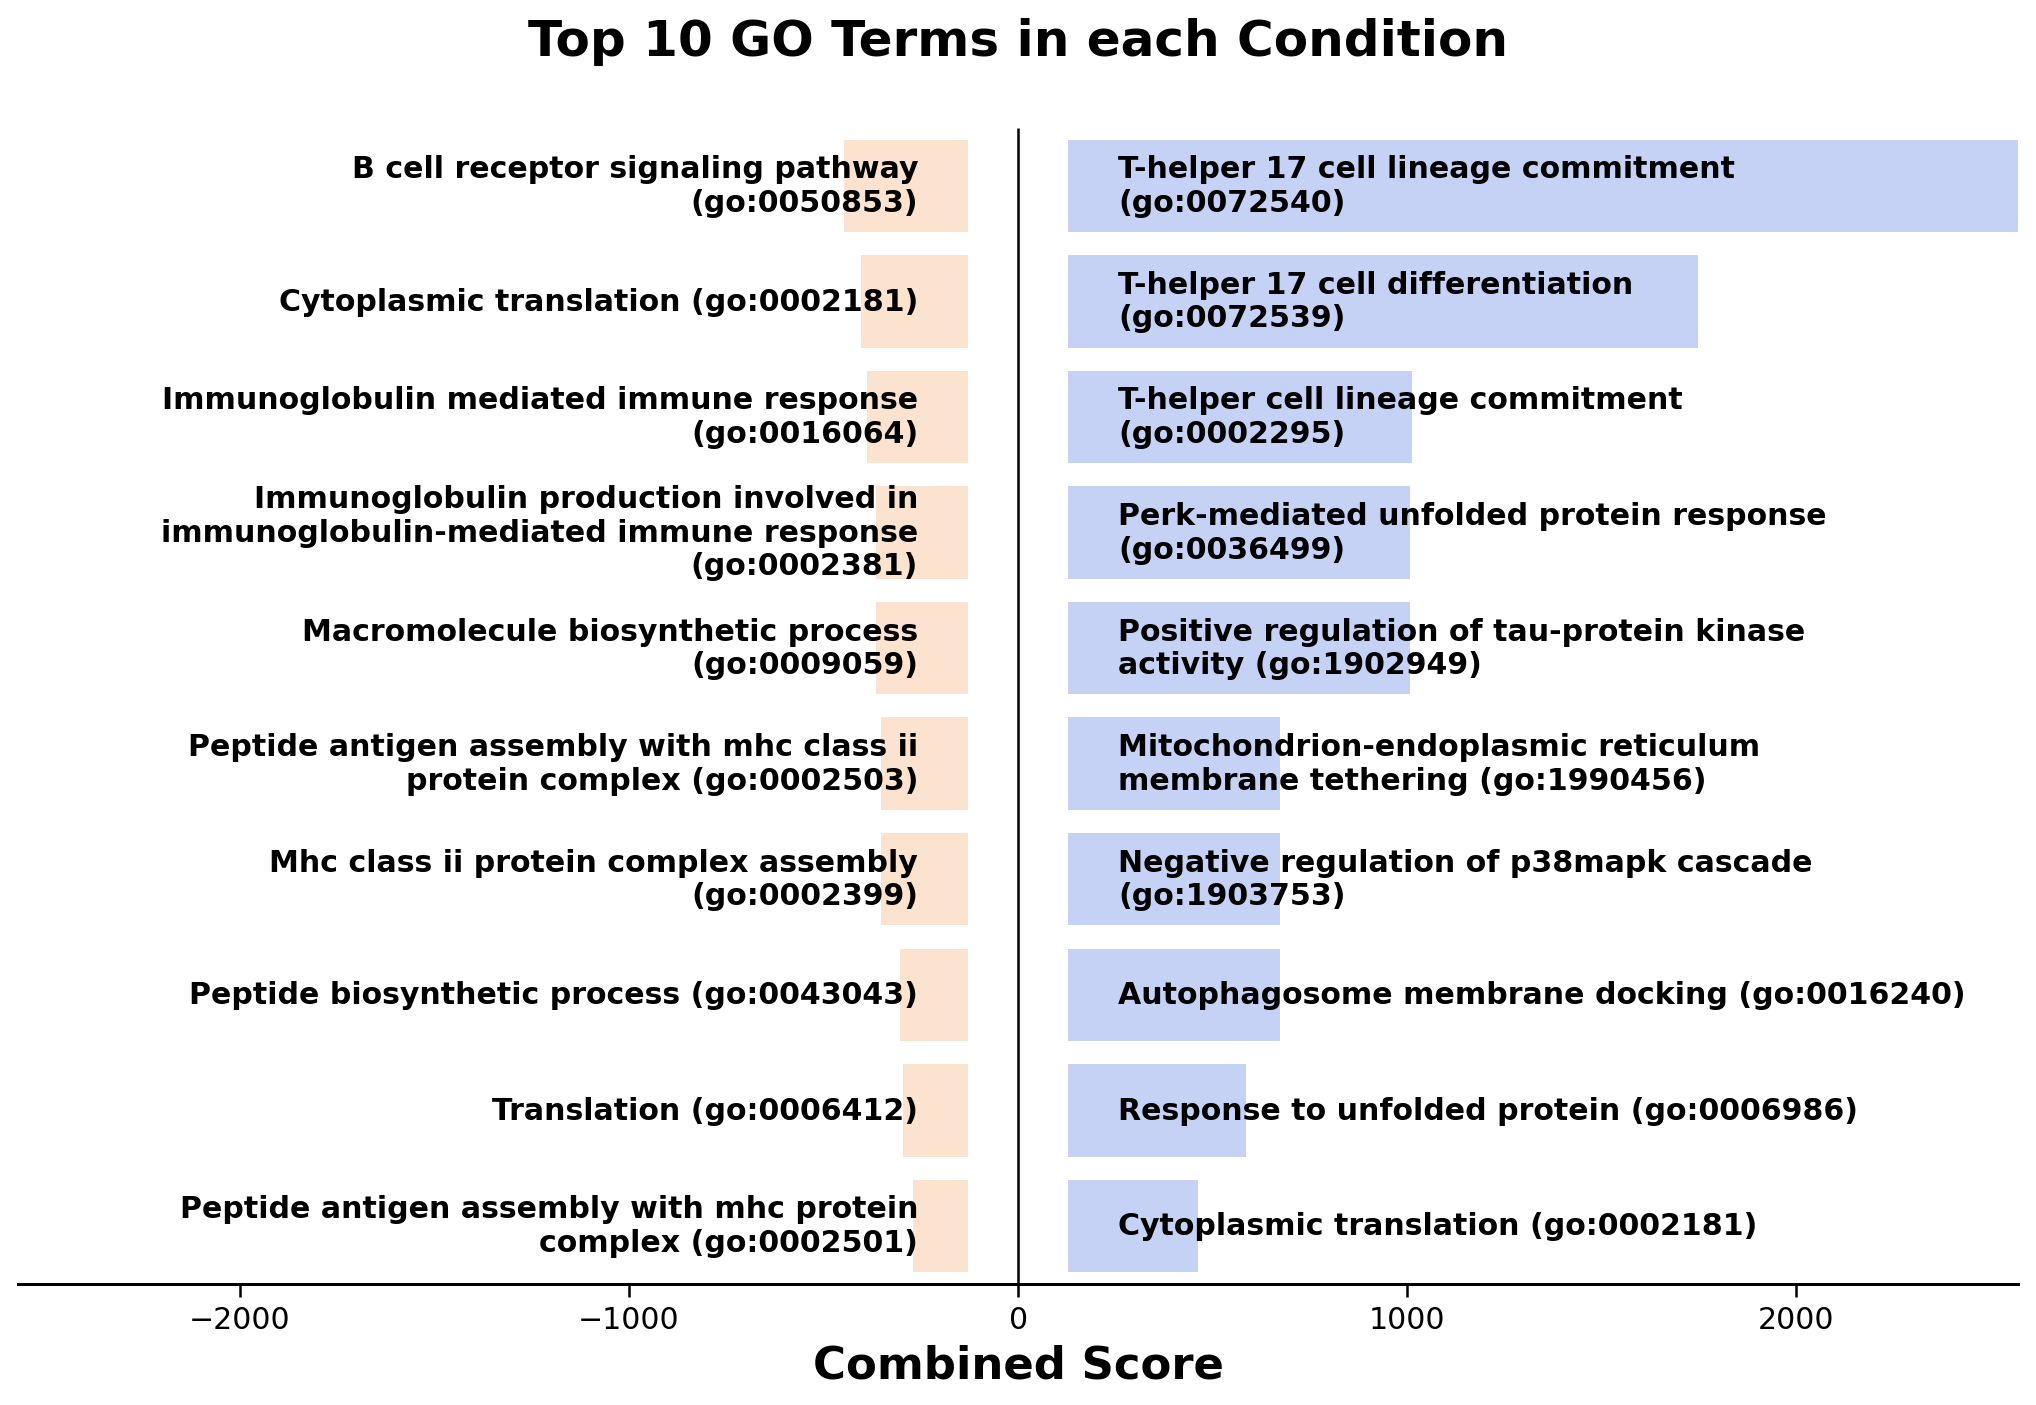

In [65]:
df_filt = df[df['Adjusted P-value'] < 0.05]
do.pl.split_bar_gsea(df_filt,
                     term_col='Term',
                     col_split='Combined Score',  # Column to use for the x-axis
                     cond_col='state',  # Column that splits the up and down-regulated terms
                     pos_cond='enriched',  # value in cond_col that should be in the positive axis
                     )

In [66]:
adata.write('/tmp/dootools_datasets/adata.h5ad')

In [67]:
!pip list

Package                       Version        Editable project location
----------------------------- -------------- --------------------------------------------------
absl-py                       2.3.0
accessible-pygments           0.0.5
adjustText                    1.3.0
aiohappyeyeballs              2.6.1
aiohttp                       3.12.12
aiosignal                     1.3.2
alabaster                     1.0.0
anndata                       0.11.4
annoy                         1.17.3
anyio                         4.9.0
archspec                      0.2.3
argon2-cffi                   23.1.0
argon2-cffi-bindings          21.2.0
array-api-compat              1.12.0
arrow                         1.3.0
asttokens                     3.0.0
async-lru                     2.0.5
async-timeout                 5.0.1
attrs                         24.3.0
babel                         2.17.0
backports.tarfile             1.2.0
bbknn                         1.6.0
beautifulsoup4                4.